In [1]:
# system,file operations
import os
import json
from collections import Counter
from google.colab import files

# data preprocessing
import numpy as np
import pandas as pd
import random

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# img processing
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # handle corrupted images

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

# model evaluation
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# utilities
import time
import copy
!pip install -q torchsummary
from torchsummary import summary

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


# path
base_path = '/content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'

# paths for each
train_path = os.path.join(base_path, 'train')
val_path = os.path.join(base_path, 'val')
test_path = os.path.join(base_path, 'test')


Device: cuda


# **IMPORTANT**

In [2]:
# paths
links = [
    # plots
    "https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/visualization/plots.py",
    # prints
    "https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/utils/printer.py",
 
    # models
    "https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/models/cnn.py",
    "https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/models/pretrained.py",
    "https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/models/scatnet.py",

    # dataset
    "https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/data/datasets.py",

    # cross-val
    "https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/training/cross_validation.py",
    # test 
    "https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/training/evaluator.py",
    # train
    "https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/training/trainer.py",
]

In [3]:
!ls

sample_data


In [ ]:
TOKEN = ""

for link in links:
    path_after_main = link.split('main/')[-1]
    dir_path = '/'.join(path_after_main.split('/')[:-1])
    !wget --header="Authorization: token {TOKEN}" -P /content/{dir_path}/ {link}

--2026-02-15 10:45:54--  https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/visualization/plots.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19672 (19K) [text/plain]
Saving to: ‘/content/src/visualization/plots.py’

plots.py            100%[===================>]  19.21K  --.-KB/s    in 0s      

2026-02-15 10:45:54 (44.4 MB/s) - ‘/content/src/visualization/plots.py’ saved [19672/19672]

--2026-02-15 10:45:54--  https://raw.githubusercontent.com/silvergjeka22/bone-fracture-detection/main/src/utils/printer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [5]:
!ls

sample_data  src


In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)
open('/root/.kaggle/kaggle.json', 'w').write('{"username":"","key":""}')
!chmod 600 /root/.kaggle/kaggle.json

In [24]:
!rm -rf /content/src/

In [19]:
!cd src

In [7]:
!ls

sample_data  src


In [8]:
from src.models.cnn import BoneFractureCNN as CNN
from src.models.pretrained import (
    BoneFractureResNet18 as R18,
    BoneFractureResNet50 as R50,
    BoneFractureVGG16 as V16,
    BoneFractureVGG19 as V19
)
from src.training.cross_validation import train_kfold_cv as kfold
from src.visualization.plots import PlotVisualizer as viz
from src.utils.printer import DatasetPrinter as dp

from src.data.datasets import BoneFractureDataset as bfd

# **Dataset SetUp**

## kaggle

In [9]:
!kaggle datasets download -d bmadushanirodrigo/fracture-multi-region-x-ray-data

Dataset URL: https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
License(s): ODC Public Domain Dedication and Licence (PDDL)
 95% 458M/481M [00:00<00:00, 412MB/s] 
100% 481M/481M [00:02<00:00, 172MB/s]


In [10]:
!unzip fracture-multi-region-x-ray-data.zip

Archive:  fracture-multi-region-x-ray-data.zip
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/0.png  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/00001.png  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/00004541.png  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/000151.png  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/000151594.png  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/0001517989.png  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/000151898.png  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/000151899789.png  
  inflating: Bone_Fracture_Binary_Cla

## Study

In [11]:
# print summary
dp.print_split_summary(base_path, train_path, val_path, test_path)


TRAIN:
 not fractured: 4640 images
 fractured: 4606 images

VAL:
 not fractured: 492 images
 fractured: 337 images

TEST:
 not fractured: 268 images
 fractured: 238 images


In [12]:
# analyze all splits
train_stats = dp.analyze_split(train_path, 'TRAIN')
val_stats = dp.analyze_split(val_path, 'VAL')
test_stats = dp.analyze_split(test_path, 'TEST')


Analyzing TRAIN

Analyzing VAL

Analyzing TEST


In [13]:
all_stats = [train_stats, val_stats, test_stats]
# print details
dp.print_all_stats(all_stats)


TRAIN:
  Total images: 9,246
    • fractured: 4,606 (49.8%)
    • not fractured: 4,640 (50.2%)
  Image dimensions:
    Width:  255 ± 164
    Height: 274 ± 228

VAL:
  Total images: 829
    • fractured: 337 (40.7%)
    • not fractured: 492 (59.3%)
  Image dimensions:
    Width:  448 ± 576
    Height: 495 ± 742

TEST:
  Total images: 506
    • fractured: 238 (47.0%)
    • not fractured: 268 (53.0%)
  Image dimensions:
    Width:  473 ± 600
    Height: 531 ± 735

TOTAL DATASET: 10,581 images


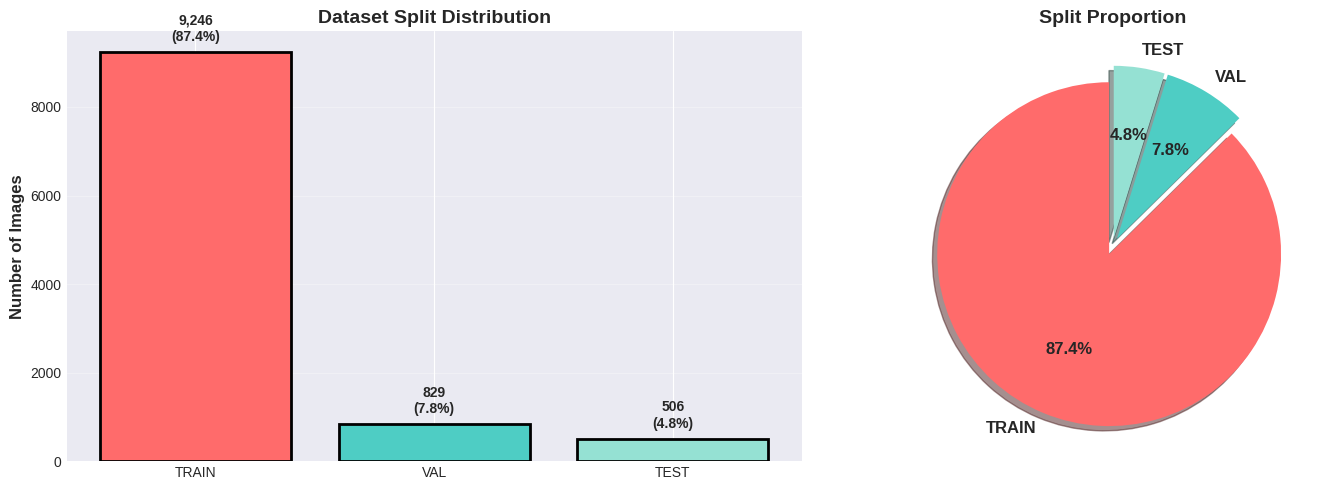

Saved: split_distribution.png


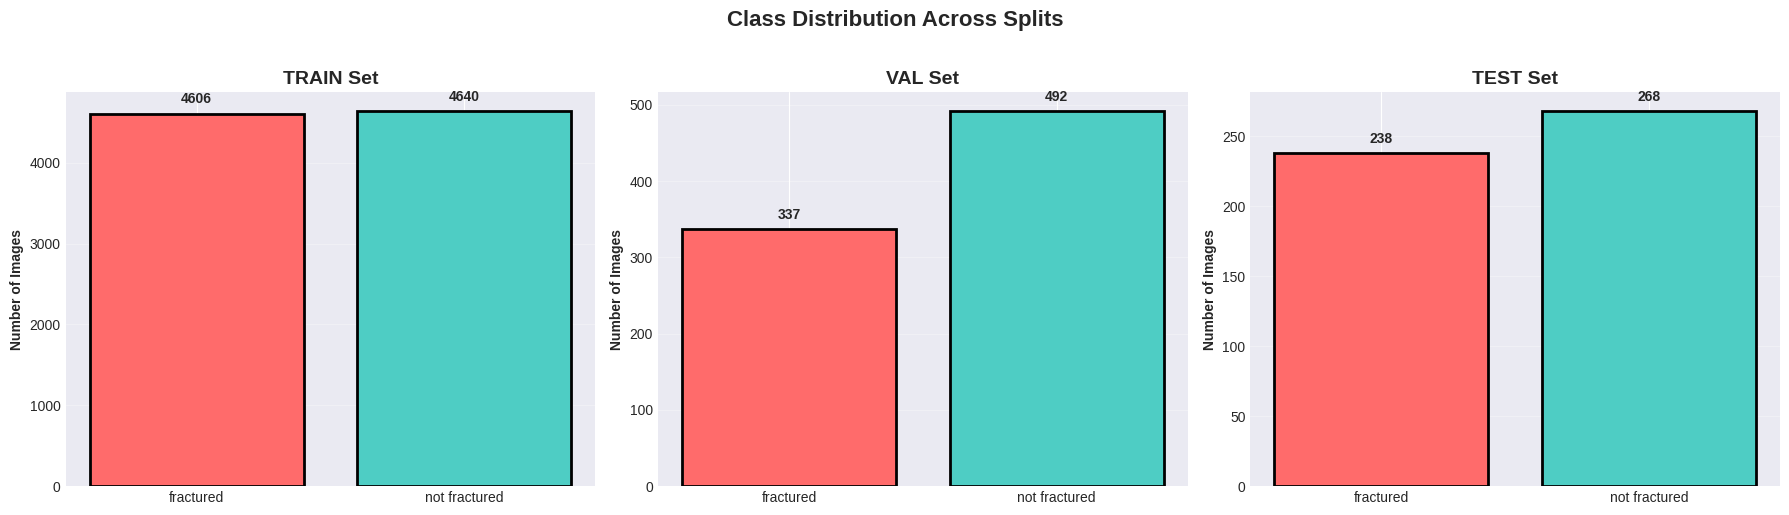

Saved: class_per_split.png


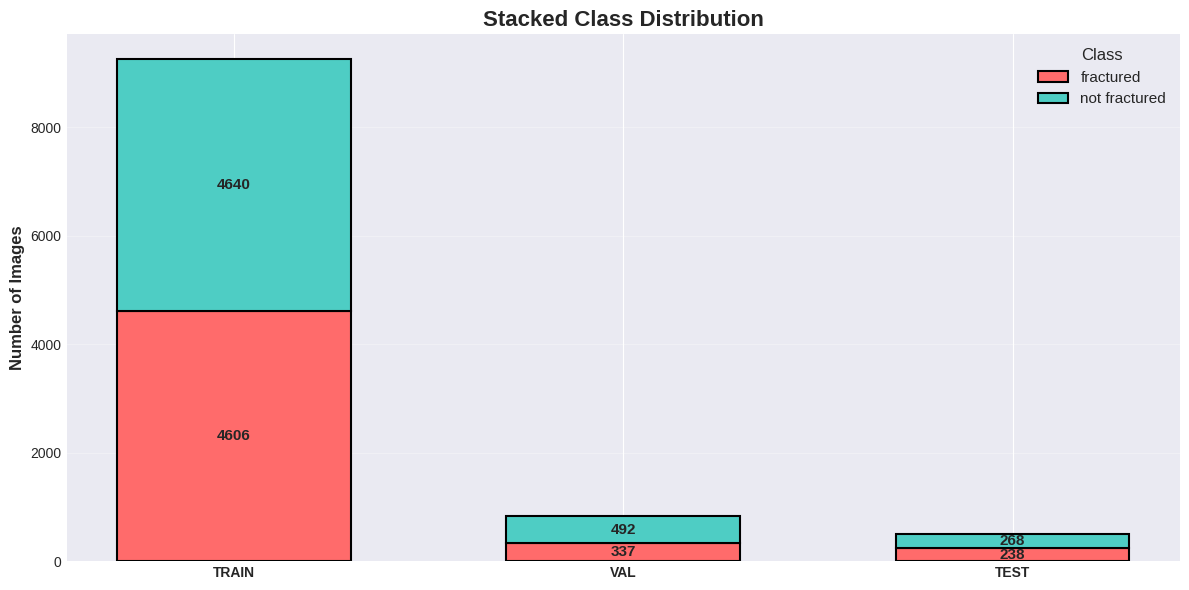

Saved: stacked_distribution.png


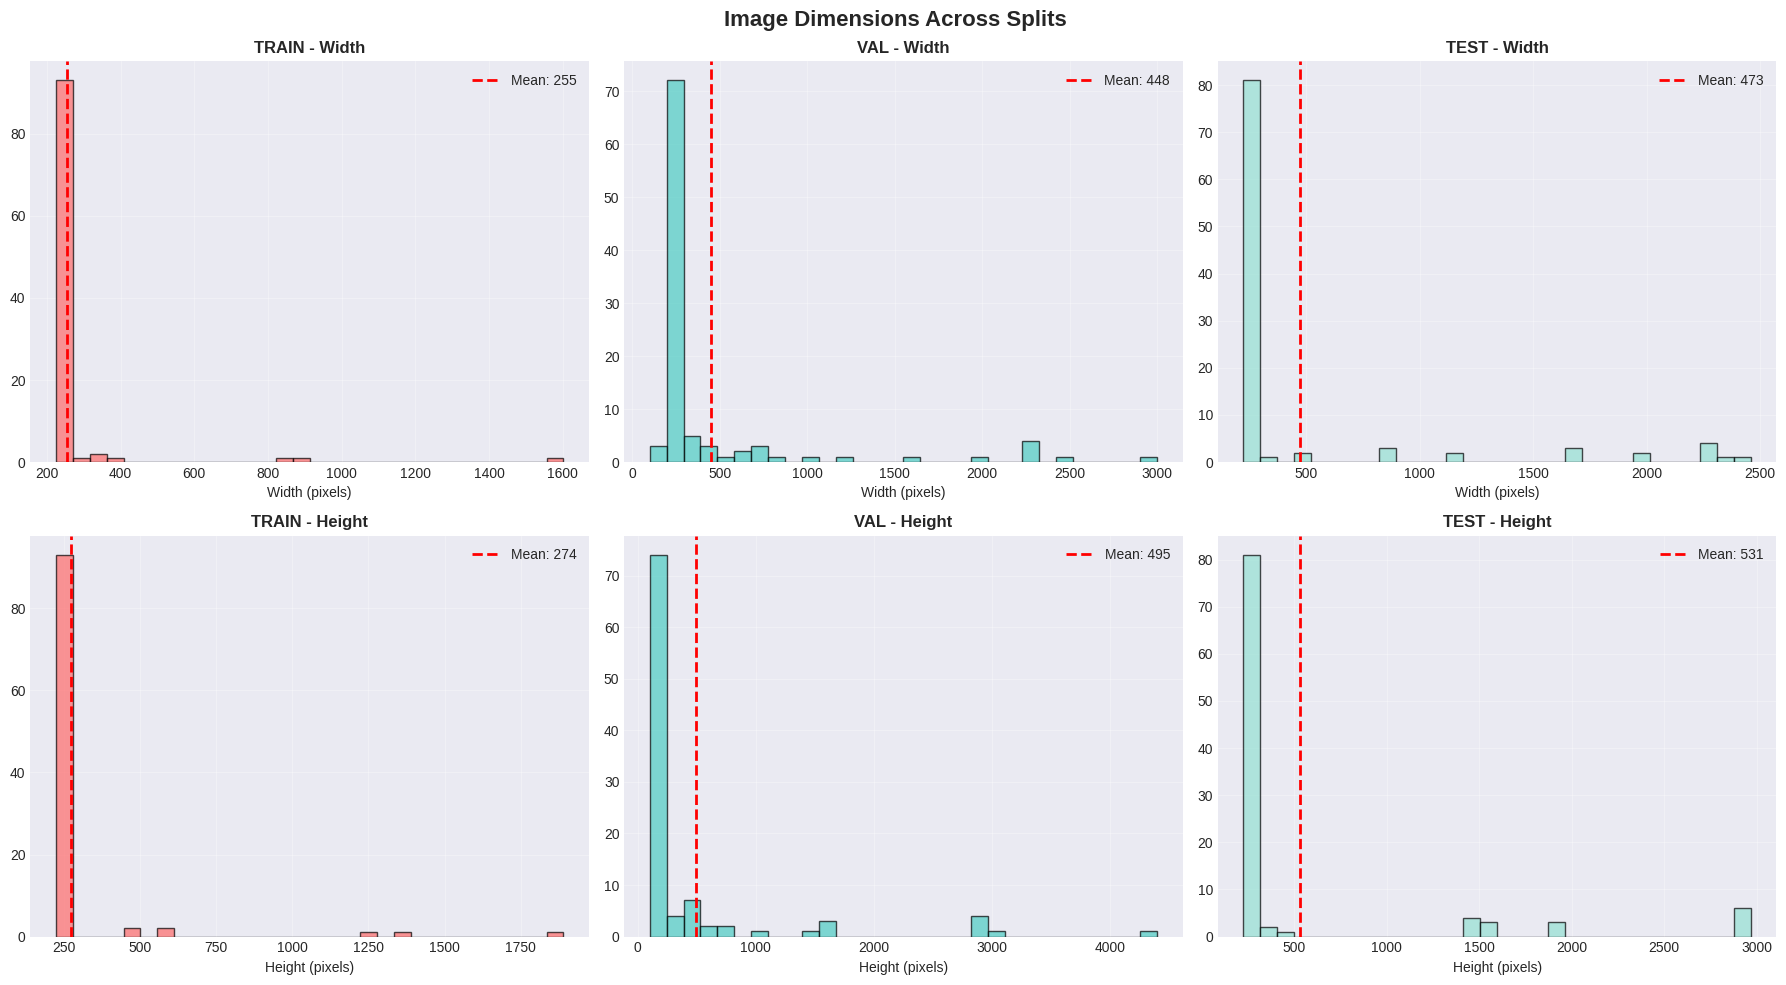

Saved: dimensions_analysis.png


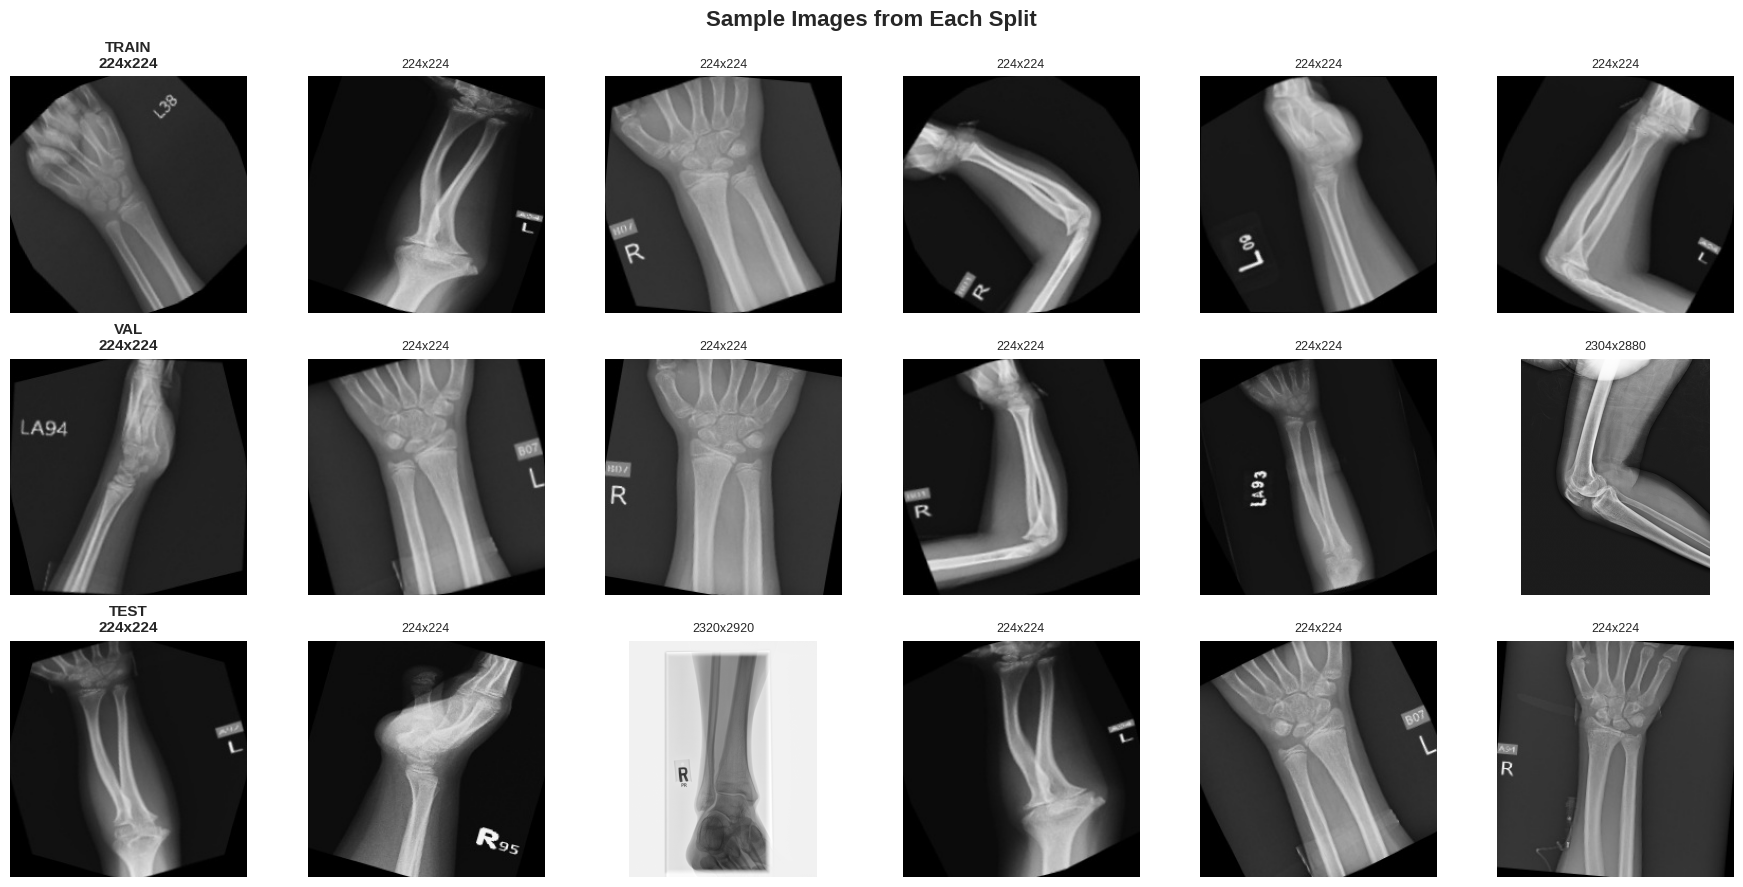

Saved: sample_images.png


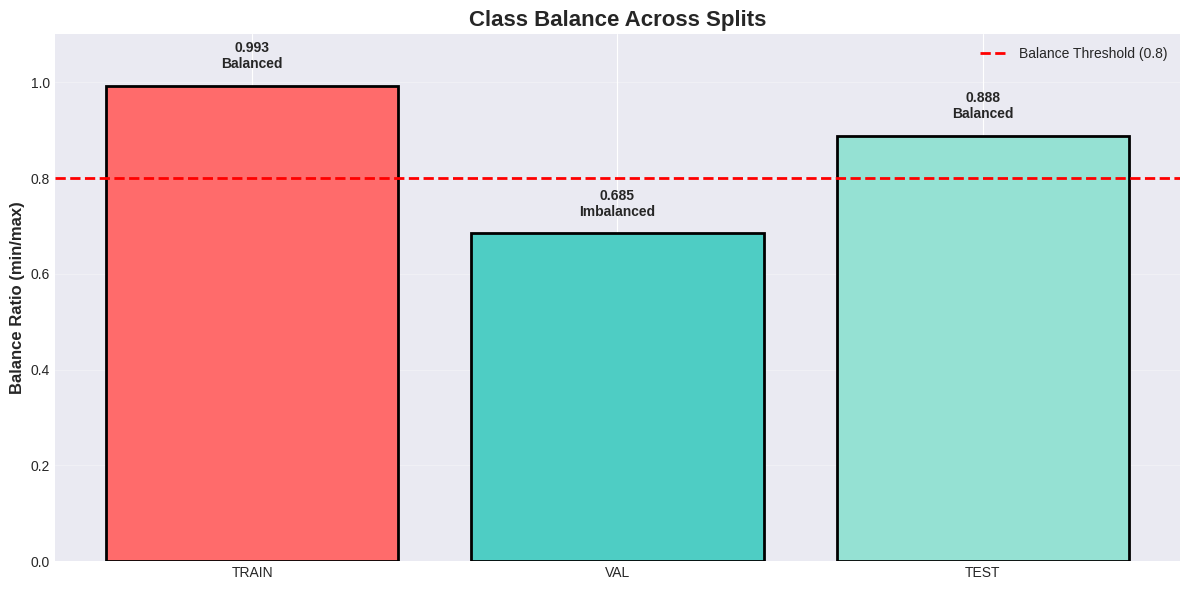

Saved: class_balance.png


In [14]:
# Now this will work!
viz.generate_all_plots(all_stats, train_path, val_path, test_path)

In [15]:
dp.print_summary_table(all_stats)

SUMMARY TABLE

 Split Total Images  Classes Avg Width Avg Height
TRAIN        9,246        2       255        274
  VAL          829        2       448        495
 TEST          506        2       473        531


# **Models Architecture**

## Augmentation

In [16]:
# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),  # ±15 degrees
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Validation/Test transforms (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

## Dataset Classes

In [17]:
train_dataset = bfd(
    root_dir=os.path.join(base_path, 'train'),
    transform=train_transform
)

val_dataset = bfd(
    root_dir=os.path.join(base_path, 'val'),
    transform=val_test_transform
)

test_dataset = bfd(
    root_dir=os.path.join(base_path, 'test'),
    transform=val_test_transform
)

print("\nDataset Summary:")
print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

Loaded 9246 images from /content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
Classes: ['fractured', 'not fractured']
Class distribution: {'fractured': 4606, 'not fractured': 4640}
Loaded 829 images from /content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val
Classes: ['fractured', 'not fractured']
Class distribution: {'fractured': 337, 'not fractured': 492}
Loaded 506 images from /content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test
Classes: ['fractured', 'not fractured']
Class distribution: {'fractured': 238, 'not fractured': 268}

Dataset Summary:
Train: 9246 images
Val:   829 images
Test:  506 images


## DataLoaders

In [18]:
BATCH_SIZE = 32
NUM_WORKERS = 2  # Adjust based on your system

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("\n")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")



Batch size: 32
Train batches: 289
Val batches:   26
Test batches:  16



Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


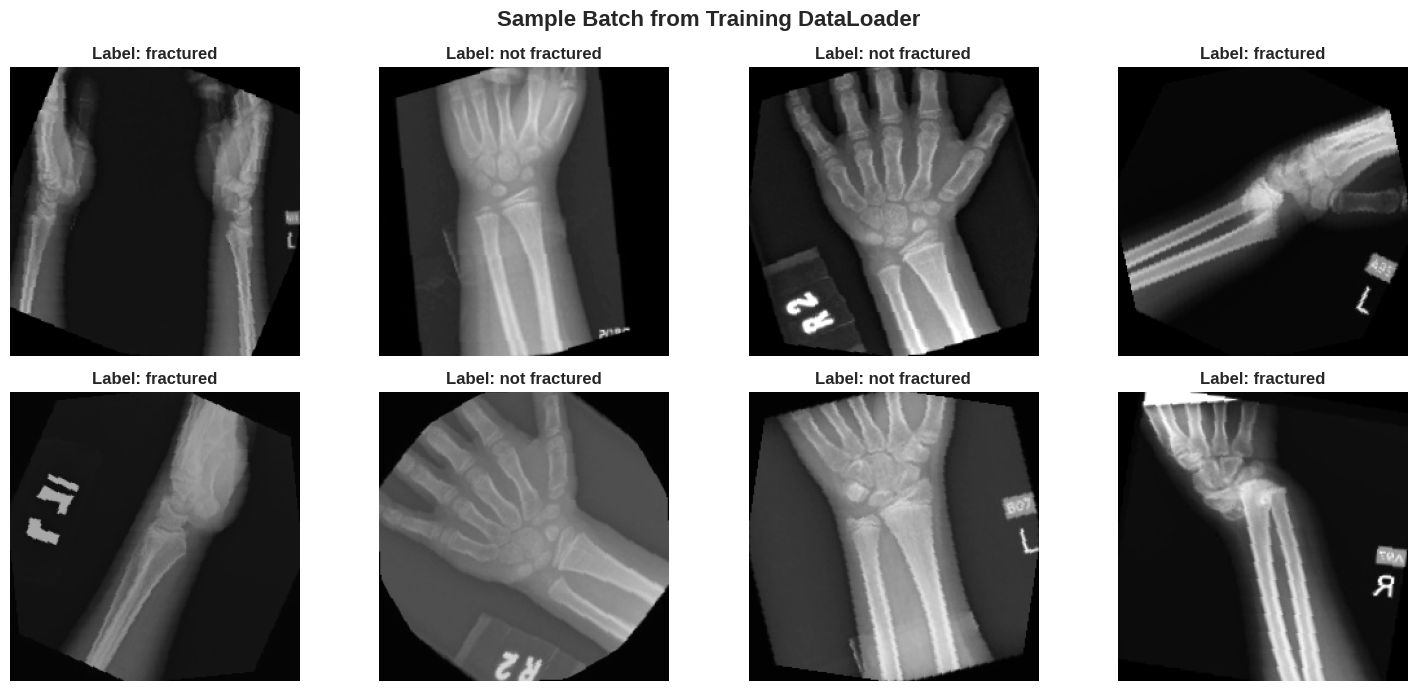

In [19]:
viz.visualize_batch(train_loader, train_dataset)

## Models

In [20]:
# Create models
print("\n1. Creating Custom CNN")
custom_cnn = CNN(num_classes=2, dropout_rate=0.5).to(device)
custom_params = dp.count_parameters(custom_cnn)
print(f" Parameters: {custom_params:,}")

print("\n2. Creating ResNet18")
resnet18_model = R18(num_classes=2, pretrained=True).to(device)
resnet18_params = dp.count_parameters(resnet18_model)
print(f" Parameters: {resnet18_params:,}")

print("\n3. Creating ResNet50")
resnet50_model = R50(num_classes=2, pretrained=True).to(device)
resnet50_params = dp.count_parameters(resnet50_model)
print(f" Parameters: {resnet50_params:,}")

print("\n4. Creating VGG16")
vgg16_model = V16(num_classes=2, pretrained=True).to(device)
vgg16_params = dp.count_parameters(vgg16_model)
print(f" Parameters: {vgg16_params:,}")

print("\n5. Creating VGG19")
vgg19_model = V19(num_classes=2, pretrained=True).to(device)
vgg19_params = dp.count_parameters(vgg19_model)
print(f" Parameters: {vgg19_params:,}")



1. Creating Custom CNN
 Parameters: 26,145,922

2. Creating ResNet18


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Parameters: 11,440,194

3. Creating ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


...

 Parameters: 136,359,234

5. Creating VGG19


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 149MB/s] 


 Parameters: 141,668,930


In [21]:
# Summary table
print("MODEL PARAMETERS COMPARISON")
print(f"{'Model':<20} {'Parameters':>15} {'Ratio vs Custom':>18}")
print("-"*70)
print(f"{'Custom CNN':<20} {custom_params:>15,} {1.0:>18.1f}x")
print(f"{'ResNet18':<20} {resnet18_params:>15,} {resnet18_params/custom_params:>18.1f}x")
print(f"{'ResNet50':<20} {resnet50_params:>15,} {resnet50_params/custom_params:>18.1f}x")
print(f"{'VGG16':<20} {vgg16_params:>15,} {vgg16_params/custom_params:>18.1f}x")
print(f"{'VGG19':<20} {vgg19_params:>15,} {vgg19_params/custom_params:>18.1f}x")

MODEL PARAMETERS COMPARISON
Model                     Parameters    Ratio vs Custom
----------------------------------------------------------------------
Custom CNN                26,145,922                1.0x
ResNet18                  11,440,194                0.4x
ResNet50                  24,558,146                0.9x
VGG16                    136,359,234                5.2x
VGG19                    141,668,930                5.4x


In [22]:
# Test forward pass
print("TESTING FORWARD PASS")
dummy_input = torch.randn(4, 3, 224, 224).to(device)

with torch.no_grad():
    out1 = custom_cnn(dummy_input)
    out2 = resnet18_model(dummy_input)
    out3 = resnet50_model(dummy_input)
    out4 = vgg16_model(dummy_input)
    out5 = vgg19_model(dummy_input)

print(f"Custom CNN output:  {out1.shape}")
print(f"ResNet18 output:    {out2.shape}")
print(f"ResNet50 output:    {out3.shape}")
print(f"VGG16 output:       {out4.shape}")
print(f"VGG19 output:       {out5.shape}")
print("\nAll models working correctly!")

TESTING FORWARD PASS
Custom CNN output:  torch.Size([4, 2])
ResNet18 output:    torch.Size([4, 2])
ResNet50 output:    torch.Size([4, 2])
VGG16 output:       torch.Size([4, 2])
VGG19 output:       torch.Size([4, 2])

All models working correctly!


In [23]:
# cnn summary
summary(custom_cnn, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
         MaxPool2d-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          18,496
       BatchNorm2d-5         [-1, 64, 112, 112]             128
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
       BatchNorm2d-8          [-1, 128, 56, 56]             256
         MaxPool2d-9          [-1, 128, 28, 28]               0
           Conv2d-10          [-1, 256, 28, 28]         295,168
      BatchNorm2d-11          [-1, 256, 28, 28]             512
        MaxPool2d-12          [-1, 256, 14, 14]               0
           Linear-13                  [-1, 512]      25,690,624
          Dropout-14                  [

In [24]:
summary(resnet18_model, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [25]:
summary(resnet50_model, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [26]:
summary(vgg16_model, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [27]:
summary(vgg19_model, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,


Filter shape: (32, 3, 3, 3)
Number of filters: 32


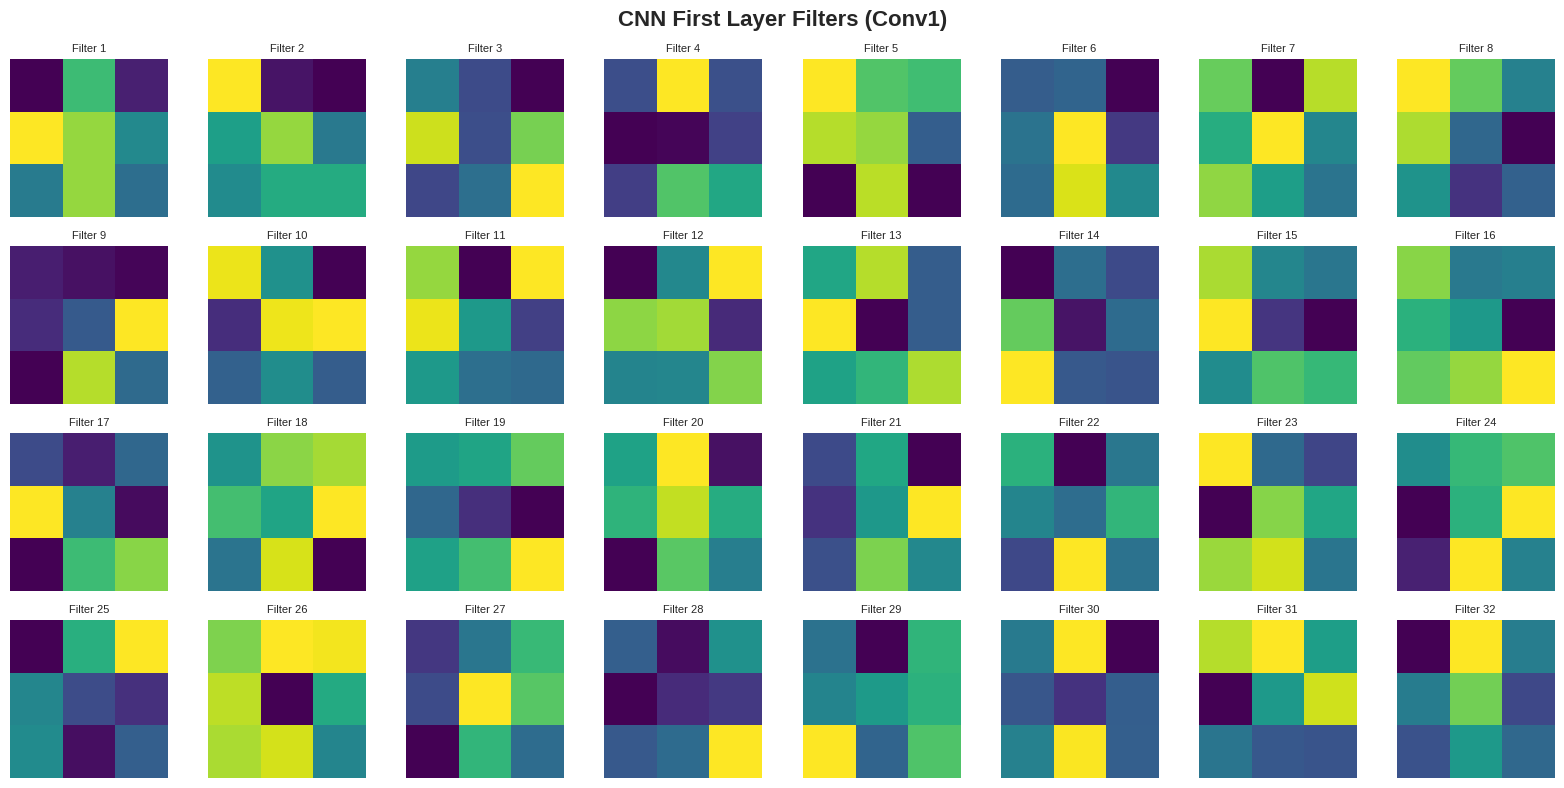

In [28]:
viz.visualize_filters(custom_cnn, save_path='cnn_initial_filters.png')


Filter shape: (64, 3, 7, 7)
Number of filters: 64


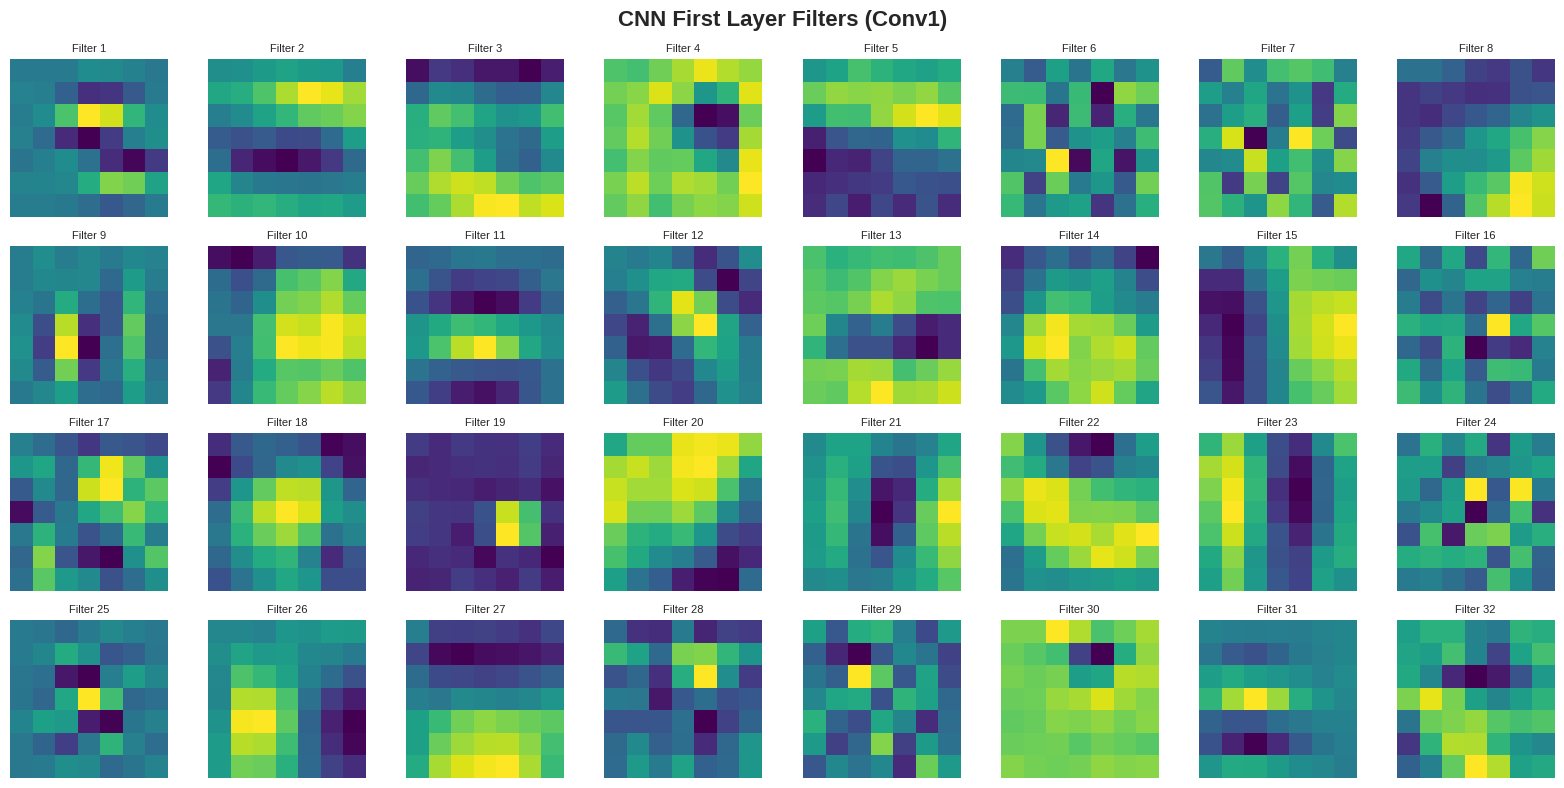

In [29]:
viz.visualize_filters(resnet18_model, save_path='resnet18_initial_filters.png')


Filter shape: (64, 3, 7, 7)
Number of filters: 64


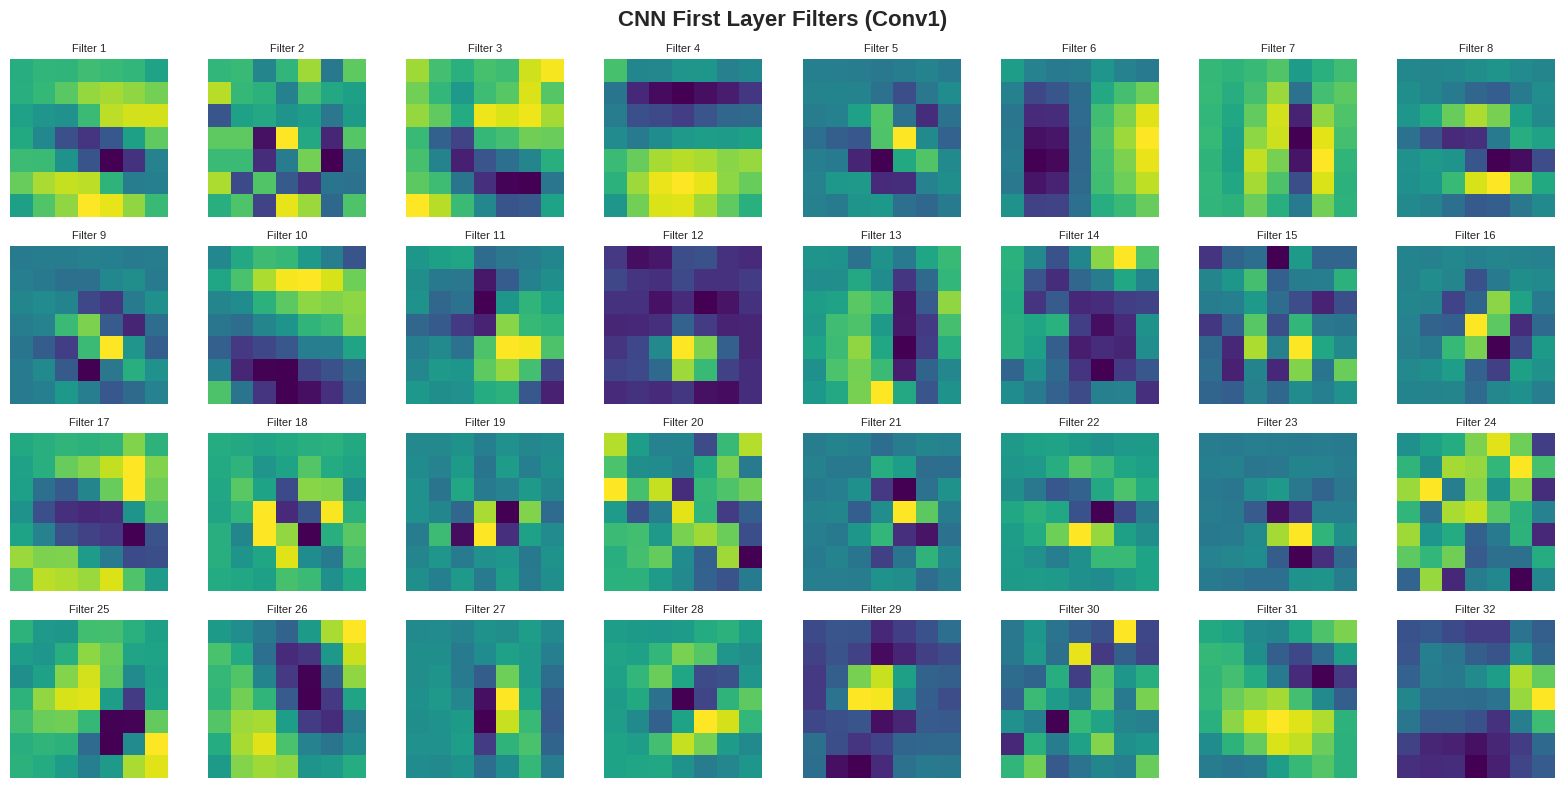

In [30]:
viz.visualize_filters(resnet50_model, save_path='resnet50_initial_filters.png')


Filter shape: (64, 3, 3, 3)
Number of filters: 64


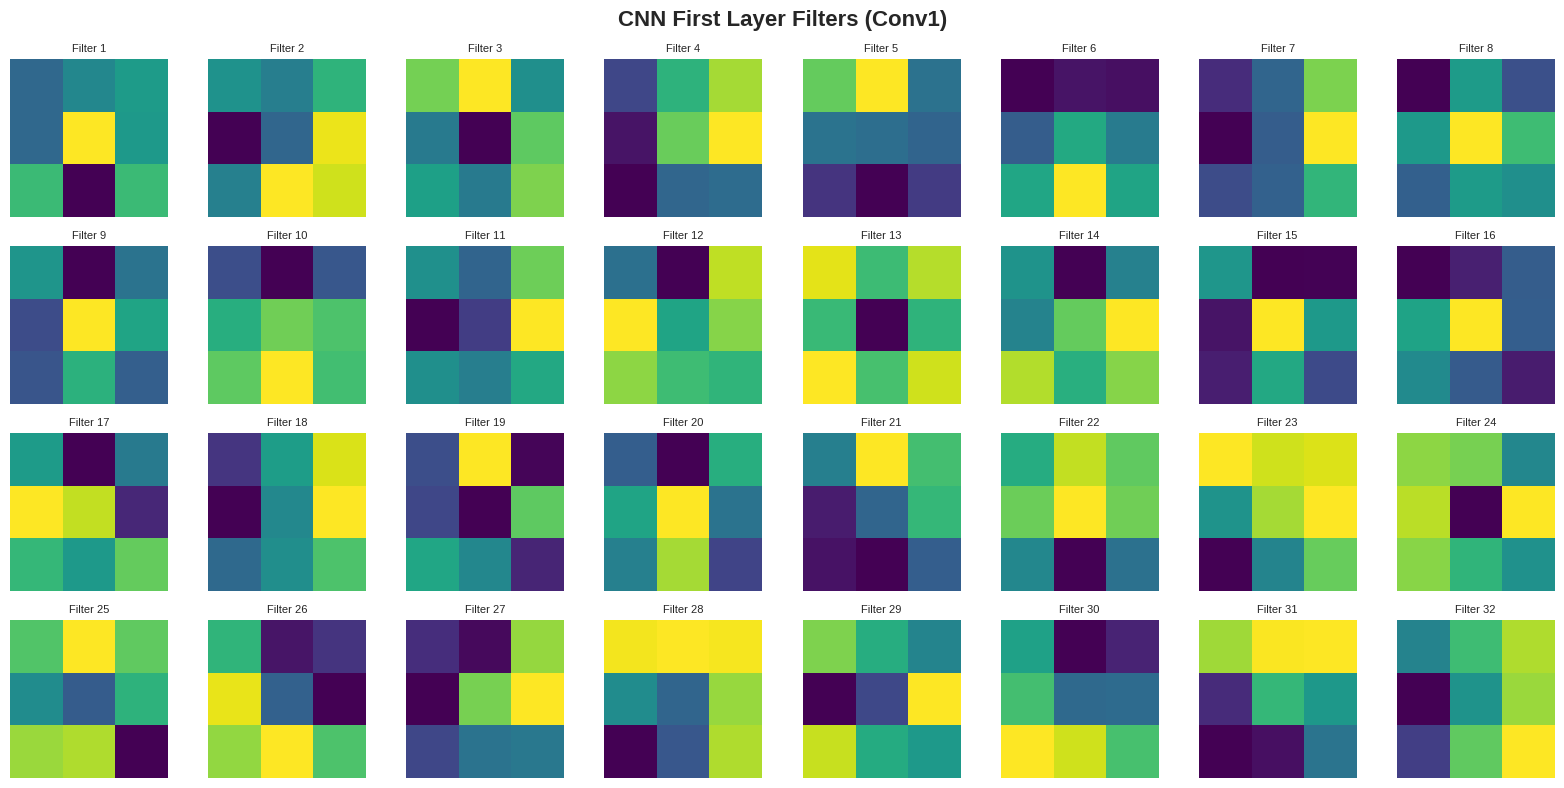

In [31]:
viz.visualize_filters(vgg16_model, save_path='vgg16_initial_filters.png')


Filter shape: (64, 3, 3, 3)
Number of filters: 64


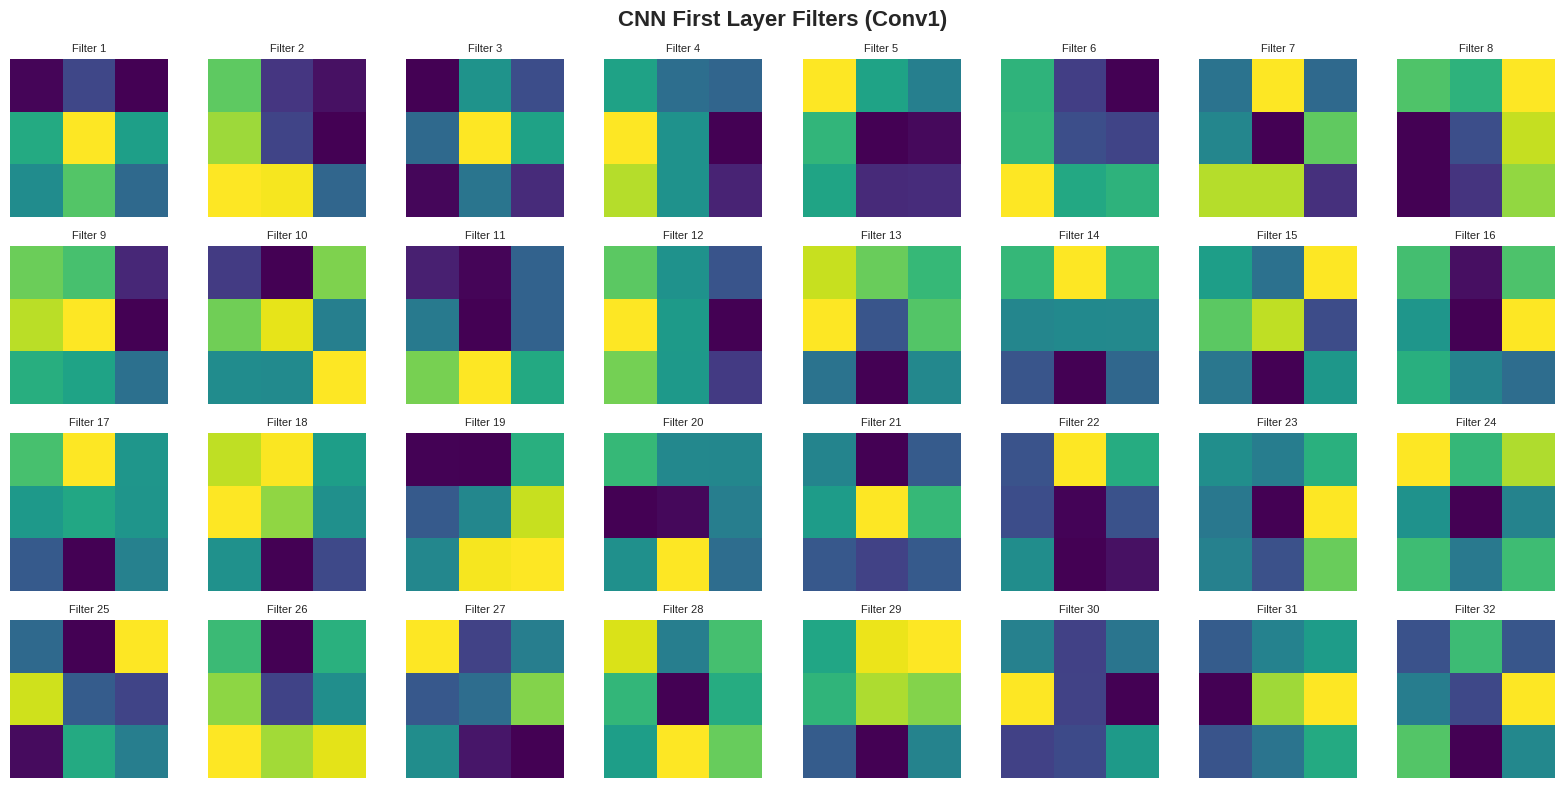

In [32]:
viz.visualize_filters(vgg19_model, save_path='vgg19_initial_filters.png')

In [33]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = custom_cnn(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([1, 1, 0, 0, 0], device='cuda:0')
Sample labels: tensor([1, 0, 1, 1, 1], device='cuda:0')

Batch accuracy (random init): 46.88%


In [34]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = resnet18_model(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([0, 1, 0, 0, 1], device='cuda:0')
Sample labels: tensor([1, 1, 1, 0, 0], device='cuda:0')

Batch accuracy (random init): 40.62%


In [35]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = resnet50_model(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([0, 0, 0, 0, 0], device='cuda:0')
Sample labels: tensor([0, 1, 0, 1, 0], device='cuda:0')

Batch accuracy (random init): 50.00%


In [36]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = vgg16_model(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([0, 0, 1, 0, 0], device='cuda:0')
Sample labels: tensor([1, 0, 0, 0, 1], device='cuda:0')

Batch accuracy (random init): 43.75%


In [37]:
# Get a batch from train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

# Forward pass
with torch.no_grad():
    outputs = vgg19_model(images)
    _, predictions = torch.max(outputs, 1)

print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:5]}")
print(f"Sample labels: {labels[:5]}")

# Calculate accuracy for this batch
correct = (predictions == labels).sum().item()
accuracy = correct / labels.size(0)
print(f"\nBatch accuracy (random init): {accuracy*100:.2f}%")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Predictions shape: torch.Size([32])
Sample predictions: tensor([0, 0, 1, 0, 1], device='cuda:0')
Sample labels: tensor([1, 1, 1, 0, 0], device='cuda:0')

Batch accuracy (random init): 53.12%


### train

In [39]:
print("TRAINING ALL MODELS WITH K-FOLD CROSS-VALIDATION")

# Training parameters
K_FOLDS = 5
NUM_EPOCHS = 25
BATCH_SIZE = 32

# Dictionary to store all results
all_results = {}

# Model configurations: (name, class, learning_rate)
models_config = [
    #('Custom CNN', CNN, 0.001),
    ('ResNet18', R18, 0.0001),
    ('ResNet50', R50, 0.0001),
    ('VGG16', V16, 0.0001),
    ('VGG19', V19, 0.0001)
]

for idx, (model_name, model_class, lr) in enumerate(models_config):
    print(f"TRAINING {idx+1}/5: {model_name.upper()}")
    print(f"Learning Rate: {lr}")
    print(f"Epochs: {NUM_EPOCHS}")
    print(f"Batch Size: {BATCH_SIZE}")
    print(f"K-Folds: {K_FOLDS}")

    # Create training function based on model type
    if model_name == 'Custom CNN':
        fold_results, fold_histories, mean_acc, std_acc = kfold(
            model_class=model_class,
            train_dataset=train_dataset,
            k_folds=K_FOLDS,
            num_epochs=NUM_EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=lr,
            device=device
        )
    else:
        # For pre-trained models
        fold_results, fold_histories, mean_acc, std_acc = kfold(
            model_class=lambda **kwargs: model_class(num_classes=2, pretrained=True),
            train_dataset=train_dataset,
            k_folds=K_FOLDS,
            num_epochs=NUM_EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=lr,
            device=device
        )

    all_results[model_name] = {
        'fold_results': fold_results,
        'fold_histories': fold_histories,
        'mean_acc': mean_acc,
        'std_acc': std_acc
    }

    print(f"\n{model_name} Training Complete!")
    print(f"Mean CV Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")

TRAINING ALL MODELS WITH K-FOLD CROSS-VALIDATION
TRAINING 1/5: RESNET18
Learning Rate: 0.0001
Epochs: 25
Batch Size: 32
K-Folds: 5
FOLD 1/5
Train size: 7396, Val size: 1850
Epoch [ 1/25] Train Loss: 0.1599 Acc: 0.9310 | Val Loss: 0.0566 Acc: 0.9795 | Time: 67.2s


KeyboardInterrupt: 

In [ ]:
vis.plot_kfold_history(fold_histories)

In [ ]:
for model_name, results in all_results.items():
    best_fold_idx = np.argmax([r['best_val_acc'] for r in results['fold_results']])
    best_model = results['fold_results'][best_fold_idx]['model']
    
    # Use new test_model function
    test_loss, test_acc, test_preds, test_labels, metrics = test_model(
        best_model, test_loader, criterion, device
    )
    
    # Access metrics directly from the dictionary
    print(f"F1: {metrics['f1']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")


In [ ]:
visualize_model_comparison(all_results, save_path='cnn_5models_comparison.png')

In [ ]:
# print details



Test F1 Score: 0.8509

Classification Report:
               precision    recall  f1-score   support

    fractured       0.85      0.80      0.82       238
not fractured       0.83      0.87      0.85       268

     accuracy                           0.84       506
    macro avg       0.84      0.84      0.84       506
 weighted avg       0.84      0.84      0.84       506


Confusion Matrix:
[[190  48]
 [ 34 234]]
